In [71]:
import pandas as pd
import pickle
from sklearn.model_selection import train_test_split
from sklearn.metrics import  mean_squared_error

In [72]:
with open("model_pickle2", "rb") as f:
        modelo = pickle.load(f)
df = pd.read_csv("kc_house_data.zip")
df = df.dropna()
df = df.drop(columns=df.columns[:2])
df.head()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,221900.0,3,1.00,1180,5650,1.0,0,0,3,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,538000.0,3,2.25,2570,7242,2.0,0,0,3,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,180000.0,2,1.00,770,10000,1.0,0,0,3,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,604000.0,4,3.00,1960,5000,1.0,0,0,5,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,510000.0,3,2.00,1680,8080,1.0,0,0,3,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [73]:
from sklearn.metrics import mean_squared_error
X= df.sqft_living.values.reshape(-1,1)
y= df.price.values.reshape(-1,1)

X_train, X_test,y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=1)

In [74]:
y_pred = modelo.predict(X_test)

In [75]:
mean_squared_error(y_test, y_pred)

85379463201.25261

In [76]:
#group2
X2 = df[["sqft_living", "grade"]]
y2 = df["price"]
df.corr()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
price,1.000000,0.308350,0.525138,0.702035,0.089661,0.256794,0.266369,0.397293,0.036362,0.667434,0.605567,0.323816,0.054012,0.126434,-0.053203,0.307003,0.021626,0.585379,0.082447
bedrooms,0.308350,1.000000,0.515884,0.576671,0.031703,0.175429,-0.006582,0.079532,0.028472,0.356967,0.477600,0.303093,0.154178,0.018841,-0.152668,-0.008931,0.129473,0.391638,0.029244
bathrooms,0.525138,0.515884,1.000000,0.754665,0.087740,0.500653,0.063744,0.187737,-0.124982,0.664983,0.685342,0.283770,0.506019,0.050739,-0.203866,0.024573,0.223042,0.568634,0.087175
sqft_living,0.702035,0.576671,0.754665,1.000000,0.172826,0.353949,0.103818,0.284611,-0.058753,0.762704,0.876597,0.435043,0.318049,0.055363,-0.199430,0.052529,0.240223,0.756420,0.183286
sqft_lot,0.089661,0.031703,0.087740,0.172826,1.000000,-0.005201,0.021604,0.074710,-0.008958,0.113621,0.183512,0.015286,0.053080,0.007644,-0.129574,-0.085683,0.229521,0.144608,0.718557
floors,0.256794,0.175429,0.500653,0.353949,-0.005201,1.000000,0.023698,0.029444,-0.263768,0.458183,0.523885,-0.245705,0.489319,0.006338,-0.059121,0.049614,0.125419,0.279885,-0.011269
waterfront,0.266369,-0.006582,0.063744,0.103818,0.021604,0.023698,1.000000,0.401857,0.016653,0.082775,0.072075,0.080588,-0.026161,0.092885,0.030285,-0.014274,-0.041910,0.086463,0.030703
view,0.397293,0.079532,0.187737,0.284611,0.074710,0.029444,0.401857,1.000000,0.045990,0.251321,0.167649,0.276947,-0.053440,0.103917,0.084827,0.006157,-0.078400,0.280439,0.072575
condition,0.036362,0.028472,-0.124982,-0.058753,-0.008958,-0.263768,0.016653,0.045990,1.000000,-0.144674,-0.158214,0.174105,-0.361417,-0.060618,0.003026,-0.014941,-0.106500,-0.092824,-0.003406
grade,0.667434,0.356967,0.664983,0.762704,0.113621,0.458183,0.082775,0.251321,-0.144674,1.000000,0.755923,0.168392,0.446963,0.014414,-0.184862,0.114084,0.198372,0.713202,0.119248


As variáveis mais importantes para prever o preço de uma casa são sqft_living e grade, pois de acordo com o coeficiente de correlação, são os que têm maior correlação com o preço

In [77]:
import numpy as np

X = np.c_[np.ones(X2.shape[0]),X2]

X_transpose = X.T
theta = np.linalg.inv(X_transpose @ X) @ (X_transpose @ y)
X

array([[1.00e+00, 1.18e+03, 7.00e+00],
       [1.00e+00, 2.57e+03, 7.00e+00],
       [1.00e+00, 7.70e+02, 6.00e+00],
       ...,
       [1.00e+00, 1.02e+03, 7.00e+00],
       [1.00e+00, 1.60e+03, 8.00e+00],
       [1.00e+00, 1.02e+03, 7.00e+00]])

In [78]:
y2_pred = X @ theta

y2_pred[:5]

array([[309390.44368979],
       [565734.52980799],
       [135223.36115671],
       [453238.20424533],
       [500155.3447485 ]])

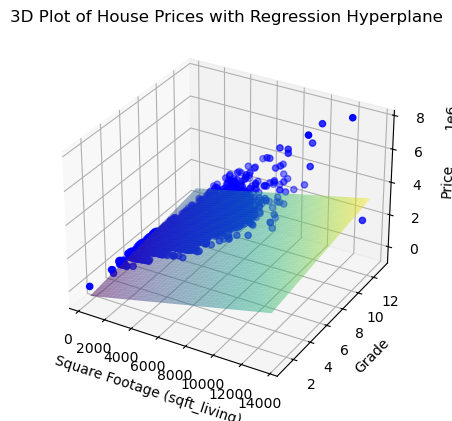

In [79]:
import matplotlib.pyplot as plt

fig = plt.figure()
axs = fig.add_subplot(111, projection='3d')

axs.scatter(X2.sqft_living, X2.grade, y2, color='blue', label='Data Points')

sqft_axis = np.linspace(X2.sqft_living.min(), X2.sqft_living.max(), 100)
grade_axis = np.linspace(X2.grade.min(), X2.grade.max(), 100)
sqfts, grades = np.meshgrid(sqft_axis, grade_axis)
prices = theta[0] + theta[1]*sqfts + theta[2]*grades

axs.set_xlabel('Square Footage (sqft_living)')
axs.set_ylabel('Grade')
axs.set_zlabel('Price')
axs.set_title('3D Plot of House Prices with Regression Hyperplane')

axs.plot_surface(sqfts, grades, prices, alpha=0.5, cmap='viridis')

plt.show()

Este modelo de regressão linear múltipla é melhor que o modelo anterior pois prevê melhor os preços das casas de acordo com as melhores features escolhidas

In [82]:
sqft_living = 2000
grade = 7 

input_features = np.array([1, sqft_living, grade])

pred_price = input_features @ theta

print("the predicted price is: ", pred_price[0])

the predicted price is:  460615.0124789427


In [86]:
from sklearn.linear_model import LinearRegression

X_train2, X_test2,y_train2, y_test2 = train_test_split(X2,y2, test_size=0.2, random_state=1)

clf = LinearRegression()

clf.fit(X2, y2)

clf.coef_

array([  184.42020584, 98554.7981385 ])

In [87]:
clf.intercept_

-598108.9861714343

In [94]:
y_pred = clf.predict(X2)
print("price is: ", y_pred[0])

price is:  309390.4436897879


/home/mike/anaconda3/lib/python3.11/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


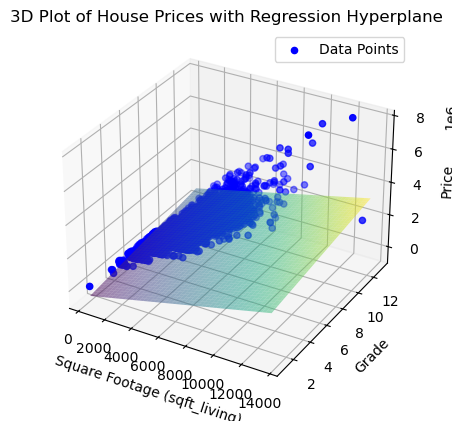

In [97]:
features = np.array([[2000, 7]])
predicted_price = clf.predict(features)

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Scatter plot of the original data points
ax.scatter(X2['sqft_living'], X2['grade'], y2, color='blue', label='Data Points')
sqft_axis = np.linspace(X2['sqft_living'].min(), X2['sqft_living'].max(), 100)
grade_axis = np.linspace(X2['grade'].min(), X2['grade'].max(), 100)
sqft_grid, grade_grid = np.meshgrid(sqft_axis, grade_axis)

price_grid = clf.intercept_ + clf.coef_[0] * sqft_grid + clf.coef_[1] * grade_grid

ax.plot_surface(sqft_grid, grade_grid, price_grid, alpha=0.5, cmap='viridis')

ax.set_xlabel('Square Footage (sqft_living)')
ax.set_ylabel('Grade')
ax.set_zlabel('Price')
ax.set_title('3D Plot of House Prices with Regression Hyperplane')

plt.legend()
plt.show()

In [100]:
print("O preço previsto é:", predicted_price[0])

O preço previsto é: 460615.01247894356


In [105]:
X3 = df[["sqft_living", "grade", "waterfront", "sqft_basement", "sqft_lot"
         , "view", "yr_built", "bedrooms", "condition", "yr_renovated", "bathrooms", "sqft_living15"
         ,"floors", "sqft_above", "sqft_lot15"]]
y3 = df["price"]

clf2 = LinearRegression()

clf2.fit(X3, y3)

clf2.coef_
clf2.intercept_

6195319.95187014

In [109]:
y_pred2 = clf2.predict(X3)

print("Preço previsto: ",y_pred2[0])

Preço previsto:  286883.4395943964
